### Plot Generation programs ###

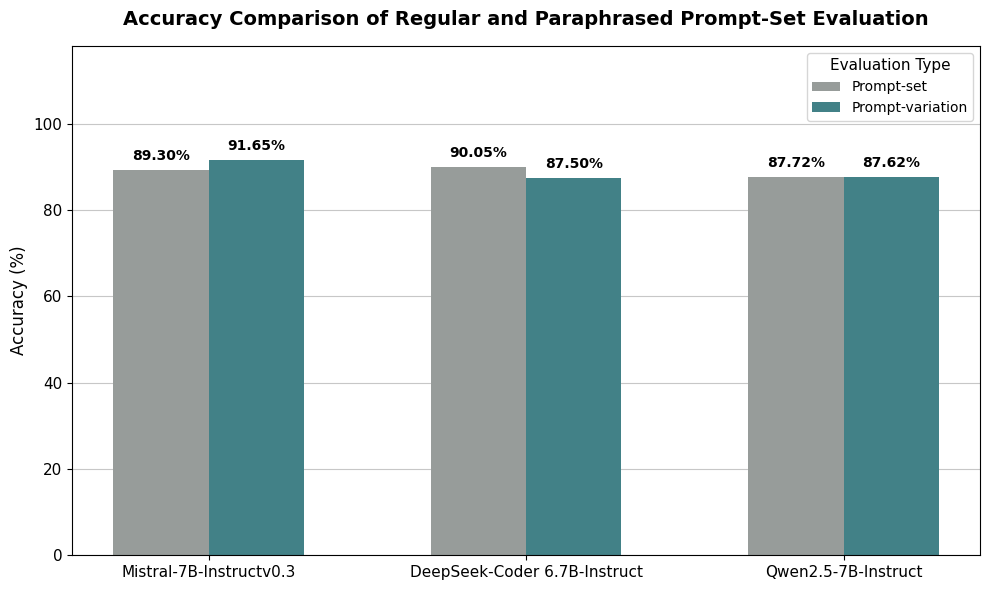

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load data from CSV
df = pd.read_csv("accuracy_variatiosnvsstandard.csv")

# Setup
models = df["Model"].unique()
x = np.arange(len(models))  # position of each model group
width = 0.30

# Accuracy by type
set_acc = df[df["Evaluation Type"].str.contains("Prompt-set")]["Accuracy"].values
var_acc = df[df["Evaluation Type"].str.contains("Prompt-variation")]["Accuracy"].values

# Colors
set_color = '#979c9a'
var_color = '#428187'

# Plot
fig, ax = plt.subplots(figsize=(10, 6))

bars_set = ax.bar(x - width/2, set_acc, width, label='Prompt-set', color=set_color)
bars_var = ax.bar(x + width/2, var_acc, width, label='Prompt-variation', color=var_color)

# Annotate bars with larger font size
def annotate_bars(bars):
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.2f}%',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 5),
                    textcoords="offset points",
                    ha='center', va='bottom',
                    fontsize=10, fontweight='bold')  # Increased font size

annotate_bars(bars_set)
annotate_bars(bars_var)

# Labels and formatting
ax.set_ylabel("Accuracy (%)", fontsize=12)  # Increased Y label size
ax.set_xlabel("", fontsize=12)         # Added X label and increased size
ax.set_title("Accuracy Comparison of Regular and Paraphrased Prompt-Set Evaluation",
             fontsize=14, weight='bold', pad=15)

ax.set_xticks(x)
ax.set_xticklabels(models, rotation=0, fontsize=11)  # Increased X tick labels
ax.set_ylim(0, 118)
ax.tick_params(axis='y', labelsize=11)  # Increased Y tick labels
ax.legend(title="Evaluation Type", fontsize=10, title_fontsize=11)

# Add horizontal gridlines behind bars
ax.set_axisbelow(True)
ax.yaxis.grid(True, alpha=0.7)

plt.tight_layout()
plt.savefig("evaluation_accuracy_comparison.png", dpi=300)
plt.show()


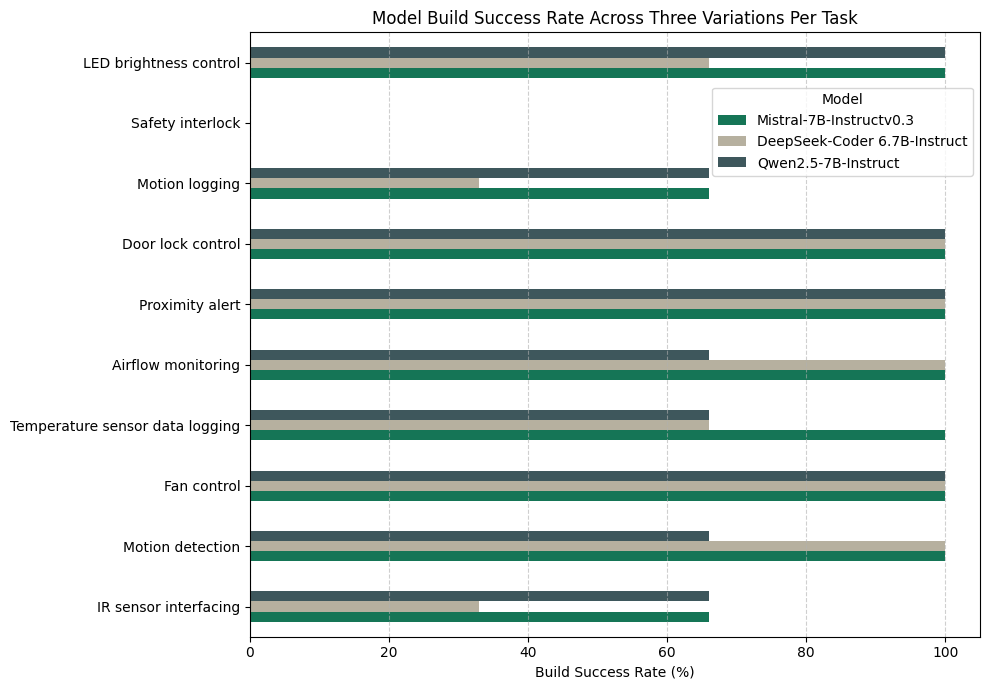

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# Sample data format
data = {
    "Task": [
        "IR sensor interfacing", "Motion detection", "Fan control", 
        "Temperature sensor data logging", "Airflow monitoring", "Proximity alert",
        "Door lock control", "Motion logging", "Safety interlock", 
        "LED brightness control"
    ],
    "Mistral-7B-Instructv0.3": [66, 100, 100, 100, 100, 100, 100, 66, 0, 100],
    "DeepSeek-Coder 6.7B-Instruct": [33, 100, 100, 66, 100, 100, 100, 33, 0, 66],
    "Qwen2.5-7B-Instruct": [66, 66, 100, 66, 66, 100, 100, 66, 0, 100]
}

df = pd.DataFrame(data)

# Plot
df.set_index("Task").plot(kind='barh', figsize=(10, 7), color=['#157556', '#B6B09F', '#3e575c'])
plt.xlabel("Build Success Rate (%)")
plt.ylabel("")
plt.title("Model Build Success Rate Across Three Variations Per Task")
plt.legend(title="Model", loc='upper right', bbox_to_anchor=(1, 0.92))  # Legend slightly below top-right
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig("Fig11.png", dpi=300)
plt.show()
